# Pandas Data Analysis Notebook

> **pandas** is a powerful Python library for data manipulation and analysis.
> Think of it as a supercharged Excel inside Python.
> It gives us two main data structures: **Series** (1D) and **DataFrame** (2D table).

## Section 1: Pandas Series - Basics

A **Series** is a one-dimensional labelled array — like a single column in a spreadsheet.
Every element has an **index** (label) associated with it.

We will start by creating a Series from a plain Python list.

In [144]:
import pandas as pd  # pandas is used for data analysis (like Excel for Python!)

# Create a simple list of numbers
a = [10, 20, 7, 18]

# pd.Series() -> converts our list into a Pandas Series
# Series is like a single column of data with index labels
var = pd.Series(a)
print(var)

0    10
1    20
2     7
3    18
dtype: int64


In [145]:
# This will print: <class 'pandas.Series'>
print(type(var))

<class 'pandas.Series'>


In [146]:
# Access a value using its index number (starts from 0)
print(var[0])  # Prints the first element (10)

# Accessing an index that doesn't exist gives ValueError
# print(var[7]) --> ValueError

10


In [147]:
# Slicing: get elements from index 0 to 9
# Since our Series only has 4 elements, it shows all of them
print(var[0:10])

0    10
1    20
2     7
3    18
dtype: int64


### Custom Index in Series

By default pandas assigns 0, 1, 2, … as index labels.
We can override that with **any** labels we want (letters, dates, names, etc.).

In [148]:
# Instead of default 0,1,2,3 we can set our OWN labels as index
var = pd.Series(a, index=['a', 'b', 'c', 'd'])
print(var)
print(var['a'])  # Now we access using our custom label 'a'
# print(var[0])  # Won't work! Because index is now 'a','b','c','d'

a    10
b    20
c     7
d    18
dtype: int64
10


### Save Series to CSV

Pandas makes it easy to export data to a CSV file with a single method call.
The file can then be opened in Excel or read back into Python later.

In [149]:
# import pandas as pd
# a = [10, 20, 7, 18]
# var = pd.Series(a)

# # .to_csv() saves the Series as a CSV (Excel-compatible) file
# # A new file called "../DataForTest/1.csv" will be created in the same folder
# var.to_csv("../DataForTest/1.csv")

## Section 2: Real Data - YouTube Subscribers (subs.csv)

Now we load **real data** from a CSV file — daily YouTube subscriber counts.
We will explore basic statistics and practice filtering the data.

In [150]:
import pandas as pd

# pd.read_csv() reads data from a CSV file into a DataFrame
sub = pd.read_csv('../T1/DataForTest/subs.csv')

# .squeeze() -> if the CSV has only 1 column, it converts DataFrame -> Series
# (like squeezing out the extra dimension)
sub = sub.squeeze()

print(sub)
print(type(sub))

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64
<class 'pandas.Series'>


In [151]:
sub

0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64

In [152]:
# .info() gives a summary of the Series:
# - Number of entries
# - Data type (int64, float64, etc.)
# - Memory used
sub.info()

<class 'pandas.Series'>
RangeIndex: 365 entries, 0 to 364
Series name: Subscribers gained
Non-Null Count  Dtype
--------------  -----
365 non-null    int64
dtypes: int64(1)
memory usage: 3.0 KB


In [153]:
# .describe() gives quick statistics:
# count = how many entries, mean = average,
# std = standard deviation (spread), min/max = smallest/biggest
sub.describe()

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64

In [154]:
# Get individual statistics directly
print(sub.max())    # Highest value in the Series
print(sub.min())    # Lowest value in the Series
print(sub.mean())   # Average of all values
print(sub.count())  # Total number of values

396
33
135.64383561643837
365


In [155]:
# .values -> gives all data as a plain NumPy array (no index)
print(sub.values)

print() 

# .index -> shows the index labels (0, 1, 2, ... in this case)
print(sub.index)

[ 48  57  40  43  44  46  33  40  44  74  49  56  49  42  39  44  54  51
  40  37  40  45  50  56  35  49  46  88  61  42  56  50  50  49  76 123
 108 110  56  62  65  66  33  66  82 126 109  88  83 108 101 128 111  96
 101  99 105  72  93  76 104  70  80  99 104 136 115 123 112 145  87  84
  92  80  70  70 132 123  98  96  88  86  92  92 110 120 105  72  84  90
  78  81  89  89  93  86  95  83  72  87 100  72  79  67  71  90  77 100
  88  65  95  78  89  96  81 105  80  66  73  68 159  90  83  76  77  66
  64  85 136 135  71  79  75  72  78 109  93  84  74  87 128 105 105  82
  86 100  88 104  87 119 118  97 114 117 102 101  96  90 114 118 113 123
 129 140 180 225 249 265 306 261 222 170 160 114 175 170 115 152 105 105
  93 110 102 136  76 105 130 146 146 105 146 150 114 113 117 108 103 108
 138 124 139 117 103 108 146 131 113 108 125  91  97  98 119 115 123 119
 127 135 137 156 160 122 111 131 192 224 254 214 236 261 247 207 254 301
 233 168 179 154 152 153 202 185 158 173 180 184 25

### Practice Questions on Series

Try to solve the question below on your own first before looking at the solution.
Two approaches are shown: a traditional **for loop** and the smarter **boolean masking**.

In [156]:
'''
    from the given find the total number of days where the sub gain are more then 150
'''
# --- Method 1: Using a for loop (traditional approach) ---
ans = 0  # Start with 0, we'll count up

for i in sub.values:        # Go through each subscriber count
    if 150 < i < 250: # Check if it's between 150 and 250
        ans += 1            # If yes, add 1 to our count

print(ans)

123


#### Method 2: Boolean Masking (Smart Way)

Instead of looping element by element, pandas lets us compare the **whole array at once**.
The result is an array of `True`/`False` values — called a **boolean mask**.
We can then use that mask to filter the Series directly.

In [157]:
''' new method '''

# Boolean masking: comparing the entire array with 150 at once
# Returns an array of True/False for each element
sub.values > 150

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False,

In [158]:
# Use the boolean mask to FILTER the Series
# Only the rows where condition = True are returned
sub[sub.values > 150]

120    159
164    180
165    225
166    249
167    265
      ... 
359    209
360    231
361    226
362    155
364    172
Name: Subscribers gained, Length: 142, dtype: int64

In [159]:
# Two ways to count how many values are > 150
print(len(sub[sub.values > 150]))   # len() method
print(sub[sub.values > 150].size)   # .size attribute (same result)

142
142


In [160]:
# Combining TWO conditions using & (AND operator)
# BOTH conditions must be True: value > 150 AND value < 250
# Note: Always wrap each condition in () when using & or |
print(sub[((sub.values > 150) & (sub.values < 250))].size)

123


## Section 3: DataFrames - Bollywood Movies (bollywood.csv)

A **DataFrame** is a 2-dimensional table (rows × columns) — like a full spreadsheet.
Here we load a Bollywood movies dataset and explore it with common DataFrame methods.
We will also use a custom row index based on movie names.

In [161]:
import pandas as pd

# Read bollywood.csv and use the 'movie' column as row index
# So instead of 0,1,2... our rows are labeled by movie name
s = pd.read_csv('../T1/DataForTest/bollywood.csv', index_col='movie')
print(s)
print(type(s))  # This is a DataFrame (2D table with rows + columns)

                                                  lead
movie                                                 
Uri: The Surgical Strike                 Vicky Kaushal
Battalion 609                              Vicky Ahuja
The Accidental Prime Minister (film)       Anupam Kher
Why Cheat India                          Emraan Hashmi
Evening Shadows                       Mona Ambegaonkar
...                                                ...
Hum Tumhare Hain Sanam                  Shah Rukh Khan
Aankhen (2002 film)                   Amitabh Bachchan
Saathiya (film)                           Vivek Oberoi
Company (film)                              Ajay Devgn
Awara Paagal Deewana                      Akshay Kumar

[1500 rows x 1 columns]
<class 'pandas.DataFrame'>


In [162]:
# .index shows all the row labels (movie names in this case)
s.index

Index(['Uri: The Surgical Strike', 'Battalion 609',
       'The Accidental Prime Minister (film)', 'Why Cheat India',
       'Evening Shadows', 'Soni (film)', 'Fraud Saiyaan', 'Bombairiya',
       'Manikarnika: The Queen of Jhansi', 'Thackeray (film)',
       ...
       'Raaz (2002 film)', 'Zameen (2003 film)', 'Waisa Bhi Hota Hai Part II',
       'Devdas (2002 Hindi film)', 'Kaante', 'Hum Tumhare Hain Sanam',
       'Aankhen (2002 film)', 'Saathiya (film)', 'Company (film)',
       'Awara Paagal Deewana'],
      dtype='str', name='movie', length=1500)

In [163]:
# NOTE: s.info without () just shows the method reference, not the result
# To actually run it, use s.info()
s.info

<bound method DataFrame.info of                                                   lead
movie                                                 
Uri: The Surgical Strike                 Vicky Kaushal
Battalion 609                              Vicky Ahuja
The Accidental Prime Minister (film)       Anupam Kher
Why Cheat India                          Emraan Hashmi
Evening Shadows                       Mona Ambegaonkar
...                                                ...
Hum Tumhare Hain Sanam                  Shah Rukh Khan
Aankhen (2002 film)                   Amitabh Bachchan
Saathiya (film)                           Vivek Oberoi
Company (film)                              Ajay Devgn
Awara Paagal Deewana                      Akshay Kumar

[1500 rows x 1 columns]>

In [164]:
# .describe() on text data shows:
# count = total entries, unique = distinct values,
# top = most frequent value, freq = how many times 'top' appears
s.describe()

,lead
count,1500
unique,566
top,Akshay Kumar
freq,48


In [165]:
"""
    for the given data set find the top 5 actor with maximum movie 
"""
# .value_counts() counts how many movies each actor has appeared in
# [0:5] gives us only the top 5 results
s.value_counts()[0:5]

lead            
Akshay Kumar        48
Amitabh Bachchan    45
Ajay Devgn          38
Salman Khan         31
Sanjay Dutt         26
Name: count, dtype: int64

## Section 4: Creating Series and DataFrame from Dictionary

Python **dictionaries** are a natural way to represent tabular data.
Pandas can convert a dict directly into a Series or a DataFrame.
Keys become column names; values become the data.

In [166]:
import pandas as pd

# Create a dictionary with student data
d = {
    'name': ["abc", 'xyz', 'pqr'],
    'marks': [10, 20, 30]
}

# Create a Series from marks, using names as index labels
marks = pd.Series(d['marks'], index=d['name'], name="marks")
print(marks.name)  # .name gives the name we assigned to the Series

marks


In [167]:
import pandas as pd

d = {
    'name': ["abc", 'xyz', 'pqr'],
    'marks': [10, 20, 30]
}

# pd.DataFrame() converts a dictionary into a 2D table
# Keys become column names, values become rows
marks = pd.DataFrame(d)
marks

,name,marks
0,abc,10
1,xyz,20
2,pqr,30


In [168]:
# .info() for DataFrame shows all columns with their data types
# and how many non-null (non-empty) values each column has
marks.info()
print()
print(type(marks))

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    3 non-null      str  
 1   marks   3 non-null      int64
dtypes: int64(1), str(1)
memory usage: 180.0 bytes

<class 'pandas.DataFrame'>


In [169]:
# include='all' shows stats for BOTH text and number columns
# Without it, describe() only shows numeric columns
marks.describe(include='all')

,name,marks
count,3,3.0
unique,3,NaN
top,abc,NaN
freq,1,NaN
mean,NaN,20.0
std,NaN,10.0
min,NaN,10.0
25%,NaN,15.0
50%,NaN,20.0
75%,NaN,25.0


## Section 5: Working with Movies Dataset (movies.csv)

We now load a larger Bollywood movies dataset (1629 movies!) and practice:
- Exploring the data with `head`, `tail`, `info`, `describe`
- Filtering rows using conditions
- Looping through column values

In [170]:
import pandas as pd

# Load the Bollywood movies dataset (1629 movies!)
data = pd.read_csv('../T1/DataForTest/movies.csv')
data  # Display the full DataFrame

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [171]:
# head(-n) -> shows ALL rows EXCEPT the last n rows
# This is different from head(n) which shows the FIRST n rows
data.head(-2)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India)
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)


In [172]:
# tail(3) -> shows the LAST 3 rows of the DataFrame
# Useful to see how the data ends
data.tail(3)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)
1628,Humsafar,tt2403201,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Humsafar,Humsafar,Humsafar,0,2011,35,Drama|Romance,9.0,2968,Sara and Ashar are childhood friends who share...,Ashar and Khirad are forced to get married due...,NaN,Fawad Khan|,NaN,TV Series (2011–2012)


In [173]:
# .info() shows:
# - Total entries (rows)
# - Each column name
# - How many non-null values (missing values show up here)
# - Data type of each column
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           1629 non-null   str    
 1   imdb_id           1629 non-null   str    
 2   poster_path       1526 non-null   str    
 3   wiki_link         1629 non-null   str    
 4   title_y           1629 non-null   str    
 5   original_title    1629 non-null   str    
 6   is_adult          1629 non-null   int64  
 7   year_of_release   1629 non-null   int64  
 8   runtime           1629 non-null   str    
 9   genres            1629 non-null   str    
 10  imdb_rating       1629 non-null   float64
 11  imdb_votes        1629 non-null   int64  
 12  story             1609 non-null   str    
 13  summary           1629 non-null   str    
 14  tagline           557 non-null    str    
 15  actors            1624 non-null   str    
 16  wins_nominations  707 non-null    str    
 17  releas

In [174]:
# describe(include='all') -> stats for ALL columns
# For numbers: mean, std, min, max, percentiles
# For text: count, unique, top (most common value), freq
data.describe(include='all')

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
count,1629,1629,1526,1629,1629,1629,1629.0,1629.000000,1629,1629,1629.000000,1629.000000,1609,1629,557,1624,707,1522
unique,1625,1623,1517,1629,1620,1621,NaN,NaN,130,205,NaN,NaN,1603,1604,553,1617,229,1063
top,Tanu Weds Manu: Returns,tt2140465,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Style,Ghost,NaN,NaN,\N,Drama,NaN,NaN,Tanu and Manu's marriage collapses. What happe...,Add a Plot »,A million-dollar fake,Kangana Ranaut|Madhavan|Jimmy Sheirgill|Swara ...,1 nomination,14 October 2016 (India)
freq,2,2,4,1,3,2,NaN,NaN,119,162,NaN,NaN,2,20,2,2,115,5
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2010.263966,NaN,NaN,5.557459,5384.263352,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5.381542,NaN,NaN,1.567609,14552.103231,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2001.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2005.000000,NaN,NaN,4.400000,233.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2011.000000,NaN,NaN,5.600000,1000.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2015.000000,NaN,NaN,6.800000,4287.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
"""
    1. Find total number of movies in year 2019
    2. Find total number of movies in year 2019 and imdb rating > 7.5
    3. Find total number of movies in year 2019 and 2018 and imdb rating > 7.5
    4. name of the movies that have WAR as genres
"""


'\n    1. Find total number of movies in year 2019\n    2. Find total number of movies in year 2019 and imdb rating > 7.5\n    3. Find total number of movies in year 2019 and 2018 and imdb rating > 7.5\n    4. name of the movies that have WAR as genres\n'

In [176]:
# Filter rows where year is 2019, then count them
# .shape returns (number_of_rows, number_of_columns)
# [0] gets just the row count
data[data["year_of_release"] == 2019].shape[0]

75

In [177]:
# TWO conditions with & (AND):
# 1. Released in 2019
# 2. IMDB rating greater than 7.5
data[(data["year_of_release"] == 2019) & (data["imdb_rating"] > 7.5)].shape[0]

15

In [178]:
# THREE conditions:
# 1. Released in 2019 OR 2018  <- using | (OR operator)
# 2. AND rating > 7.5
# Brackets order matters: (year condition) AND (rating condition)
data[((data["year_of_release"] == 2019) | (data["year_of_release"] == 2018)) & (data["imdb_rating"] > 7.5)].shape[0]

26

In [179]:
j = 0  # To track current row number

for i in data['genres']:        # Loop over genres column (one genre string per movie)
    temp = i.strip('|')         # Remove | from start and end of genre string
    if 'War' in temp:           # Check if 'War' is one of the genres
        print(data['original_title'][j], ":", i)  # Print movie title and its genres
    j += 1                      # Move to next row

Uri: The Surgical Strike : Action|Drama|War
Battalion 609 : War
The Ghazi Attack : Action|Thriller|War
Tubelight : Drama|War
Welcome to Karachi : Action|Comedy|War
Kya Dilli Kya Lahore : Drama|History|War
Children of War : Drama|History|War
War Chod Na Yaar : Comedy|War
Chittagong : Action|Drama|War
Gandhi to Hitler : Drama|History|War
Mausam : Drama|Romance|War
1971 : Action|Drama|War
Ab Tumhare Hawale Watan Saathiyo : Action|Drama|War
LOC: Kargil : Drama|History|War
LOC: Kargil : Drama|History|War
Jang Aur Aman : Documentary|War


## Section 6: IPL Matches Dataset (ipl-matches.csv)

Time to analyse cricket data!
This dataset contains results of **950 IPL matches** across multiple seasons.
We will practice multi-condition filtering and calculate win percentages.

In [180]:
import pandas as pd

# Load IPL match history data
# This dataset has 950 IPL matches from multiple seasons
data = pd.read_csv('../T1/DataForTest/ipl-matches.csv')

In [181]:
# head(10) -> show the first 10 rows
# Good way to quickly explore what the data looks like
data.head(10)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
5,1304115,Mumbai,2022-05-21,2022,69,Delhi Capitals,Mumbai Indians,"Wankhede Stadium, Mumbai",Mumbai Indians,field,N,Mumbai Indians,Wickets,5.0,NaN,JJ Bumrah,"['PP Shaw', 'DA Warner', 'MR Marsh', 'RR Pant'...","['Ishan Kishan', 'RG Sharma', 'D Brevis', 'Til...",Nitin Menon,Tapan Sharma
6,1304114,Mumbai,2022-05-20,2022,68,Chennai Super Kings,Rajasthan Royals,"Brabourne Stadium, Mumbai",Chennai Super Kings,bat,N,Rajasthan Royals,Wickets,5.0,NaN,R Ashwin,"['RD Gaikwad', 'DP Conway', 'MM Ali', 'N Jagad...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,NA Patwardhan
7,1304113,Mumbai,2022-05-19,2022,67,Gujarat Titans,Royal Challengers Bangalore,"Wankhede Stadium, Mumbai",Gujarat Titans,bat,N,Royal Challengers Bangalore,Wickets,8.0,NaN,V Kohli,"['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...","['V Kohli', 'F du Plessis', 'GJ Maxwell', 'KD ...",KN Ananthapadmanabhan,GR Sadashiv Iyer
8,1304112,Navi Mumbai,2022-05-18,2022,66,Lucknow Super Giants,Kolkata Knight Riders,"Dr DY Patil Sports Academy, Mumbai",Lucknow Super Giants,bat,N,Lucknow Super Giants,Runs,2.0,NaN,Q de Kock,"['Q de Kock', 'KL Rahul', 'E Lewis', 'DJ Hooda...","['VR Iyer', 'A Tomar', 'N Rana', 'SS Iyer', 'S...",R Pandit,YC Barde
9,1304111,Mumbai,2022-05-17,2022,65,Sunrisers Hyderabad,Mumbai Indians,"Wankhede Stadium, Mumbai",Mumbai Indians,field,N,Sunrisers Hyderabad,Runs,3.0,NaN,RA Tripathi,"['Abhishek Sharma', 'PK Garg', 'RA Tripathi', ...","['RG Sharma', 'Ishan Kishan', 'DR Sams', 'Tila...",CB Gaffaney,N Pandit


In [182]:
# .info() tells us about all 20 columns in the IPL dataset
# Also shows which columns have missing (NaN) values
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    str    
 2   Date             950 non-null    str    
 3   Season           950 non-null    str    
 4   MatchNumber      950 non-null    str    
 5   Team1            950 non-null    str    
 6   Team2            950 non-null    str    
 7   Venue            950 non-null    str    
 8   TossWinner       950 non-null    str    
 9   TossDecision     950 non-null    str    
 10  SuperOver        946 non-null    str    
 11  WinningTeam      946 non-null    str    
 12  WonBy            950 non-null    str    
 13  Margin           932 non-null    float64
 14  method           19 non-null     str    
 15  Player_of_Match  946 non-null    str    
 16  Team1Players     950 non-null    str    
 17  Team2Players     950 non-nu

In [183]:
# .describe() shows stats for numeric columns: ID and Margin
# Margin shows by how many runs/wickets teams won
data.describe()

,ID,Margin
count,9.500000e+02,932.000000
mean,8.304852e+05,17.056867
std,3.375678e+05,21.633109
min,3.359820e+05,1.000000
25%,5.012612e+05,6.000000
50%,8.297380e+05,8.000000
75%,1.175372e+06,19.000000
max,1.312200e+06,146.000000


### Practice Questions on IPL Data

Try answering these questions using the filtering techniques we have learned.
Think about which columns to use and how to combine conditions with `&` and `|`.

In [184]:
"""
    1. find the number of mathch that want till super over
    2. CSK won toss bat first and won 
    2. CSK won toss bat first and won and find % of matches won 
"""

'\n    1. find the number of mathch that want till super over\n    2. CSK won toss bat first and won \n    2. CSK won toss bat first and won and find % of matches won \n'

In [185]:
# SuperOver == 'Y' means the match ended in a TIE and went to Super Over
# Count how many such matches happened
data[data['SuperOver'] == 'Y'].shape[0]

14

In [186]:
# Count matches where:
# 1. CSK played (either as Team1 or Team2)
# 2. CSK won the toss
# 3. CSK decided to bat first (TossDecision == 'bat')
# 4. CSK won the match
data[((data['Team1'] == 'Chennai Super Kings') | (data['Team2'] == 'Chennai Super Kings'))
     & ((data['TossDecision'] == 'bat')) & ((data['WinningTeam'] == 'Chennai Super Kings')) & (data['TossWinner'] == 'Chennai Super Kings')].shape[0]

33

In [187]:
# Count total matches where CSK won toss AND batted first
# (regardless of whether they won or lost the match)
# This will be used as the denominator for win percentage
data[((data['Team1'] == 'Chennai Super Kings') | (data['Team2'] == 'Chennai Super Kings'))
     & ((data['TossDecision'] == 'bat')) & (data['TossWinner'] == 'Chennai Super Kings')].shape[0]

55

In [188]:
# Win Percentage formula: (wins / total_games) * 100
# CSK won 33 matches out of 55 where they batted first after winning toss
print((33 / 55) * 100)

60.0


## Section 7: Data Analysis Workflow (Data.csv)

Now we follow the **complete data analysis workflow** step by step:
1. **Data Inspection** — understand what your data looks like
2. **Data Handling** — remove unwanted columns, select specific rows/columns
3. **Data Cleaning** — handle missing (NaN) values
4. **Data Transformation** — create new columns, remove duplicates, correlations

In [189]:
"""
    Data Analysis Steps:
    1. Data Inspection      --> head(), tail(), shape, columns, info(), describe(), loc/iloc
    2. Data Handling         --> drop()
    3. Data Cleaning         --> dropna(), fillna(), isnull(), isna()
    4. Data Transformation   --> creating new columns, drop_duplicates(), corr()
"""

import pandas as pd  # Import pandas for data analysis

# read_csv() -> reads a CSV file and loads it into a DataFrame
# "../DataForTest/Data.csv" means go one folder up, then into DataForTest folder
data = pd.read_csv("../T1/DataForTest/Data.csv")

# print() displays the entire DataFrame
print(data)

    Unnamed: 0  Enroll    Name Branch  CGPA Intern_Company  Stipend  \
0            0     101   Arjun    CSE   8.2            TCS  15000.0   
1            1     102    Riya     IT   7.5        Infosys  12000.0   
2            2     103   Karan    CSE   9.1            NaN  20000.0   
3            3     104   Meera     CE   6.8          Wipro      NaN   
4            4     105     Dev     IT   8.0      Capgemini  14000.0   
5            5     106  Anjali    CSE   7.2            TCS  15000.0   
6            6     107   Rohit     CE   6.5            NaN  10000.0   
7            7     108   Pooja     IT   8.7        Infosys  12000.0   
8            8     109    Amit    CSE   9.5         Google  50000.0   
9            9     110    Neha     CE   7.0          Wipro  11000.0   
10          10     111   Arjun    CSE   8.2            TCS  15000.0   
11          11     112   Sneha     IT   NaN      Capgemini  14000.0   
12          12     113  Vikram    CSE   7.8            NaN  18000.0   
13    

### Step 1: Data Inspection

Before doing any analysis, you must **understand your data** first.
Use `head()`, `shape`, `columns`, `info()`, and `describe()` to get a complete picture.

In [190]:
# head() -> shows the first 5 rows of the DataFrame by default
# Useful for a quick preview of your data
data.head()

,Unnamed: 0,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed
0,0,101,Arjun,CSE,8.2,TCS,15000.0,85.0,Ahmedabad,Python,Yes
1,1,102,Riya,IT,7.5,Infosys,12000.0,78.0,Surat,Java,No
2,2,103,Karan,CSE,9.1,NaN,20000.0,92.0,Ahmedabad,Python,Yes
3,3,104,Meera,CE,6.8,Wipro,NaN,65.0,Vadodara,C++,No
4,4,105,Dev,IT,8.0,Capgemini,14000.0,88.0,Surat,Java,Yes


In [191]:
# shape -> returns (rows, columns) as a tuple
# Tells you how big your dataset is
data.shape  # (row, col)

(14, 11)

In [192]:
# columns -> returns the column names of the DataFrame (as an Index object)
print(data.columns)
print()
# type() shows that columns returns a pandas Index, not a regular list
print(type(data.columns))

Index(['Unnamed: 0', 'Enroll', 'Name', 'Branch', 'CGPA', 'Intern_Company',
       'Stipend', 'Attendance', 'City', 'Skills', 'Placed'],
      dtype='str')

<class 'pandas.Index'>


In [193]:
# to_list() -> converts the Index object into a regular Python list
# Easier to work with if you need column names as a list
print(data.columns.to_list())
print()
# Now the type is a plain Python list instead of pandas Index
print(type(data.columns.to_list()))

['Unnamed: 0', 'Enroll', 'Name', 'Branch', 'CGPA', 'Intern_Company', 'Stipend', 'Attendance', 'City', 'Skills', 'Placed']

<class 'list'>


In [194]:
# info() -> gives a summary of the DataFrame:
#   - Total rows and columns
#   - Column names and their data types (int, float, object, etc.)
#   - Non-null count (helps spot missing values quickly)
#   - Memory usage
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      14 non-null     int64  
 1   Enroll          14 non-null     int64  
 2   Name            14 non-null     str    
 3   Branch          14 non-null     str    
 4   CGPA            13 non-null     float64
 5   Intern_Company  11 non-null     str    
 6   Stipend         13 non-null     float64
 7   Attendance      13 non-null     float64
 8   City            13 non-null     str    
 9   Skills          14 non-null     str    
 10  Placed          14 non-null     str    
dtypes: float64(3), int64(2), str(6)
memory usage: 1.3 KB


In [195]:
# describe() -> gives statistical summary of numeric columns:
#   - count, mean, std (standard deviation)
#   - min, 25%, 50% (median), 75%, max
# Only works on numeric columns (int, float)
data.describe()

,Unnamed: 0,Enroll,CGPA,Stipend,Attendance
count,14.0000,14.0000,13.000000,13.000000,13.000000
mean,6.5000,107.5000,7.846154,16769.230769,80.615385
std,4.1833,4.1833,0.894069,10361.417584,10.468512
min,0.0000,101.0000,6.500000,10000.000000,60.000000
25%,3.2500,104.2500,7.200000,12000.000000,78.000000
50%,6.5000,107.5000,7.800000,14000.000000,82.000000
75%,9.7500,110.7500,8.200000,15000.000000,88.000000
max,13.0000,114.0000,9.500000,50000.000000,95.000000


### Step 2: Data Handling

Now we **clean up the structure** of our DataFrame:
- Remove unwanted columns with `drop()`
- Select specific rows and columns with `loc[]` and `iloc[]`
- Create new calculated columns

In [196]:
# drop(columns=[...]) -> removes unwanted columns from the DataFrame
# "Unnamed: 0" is an extra index column that sometimes appears when reading CSV
data = data.drop(columns=['Unnamed: 0'])

# OR you can use inplace=True to modify the original DataFrame directly:
# data.drop(columns=['Unnamed: 0'], inplace=True)

In [197]:
# Just typing the variable name displays the DataFrame in a nice table format
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed
0,101,Arjun,CSE,8.2,TCS,15000.0,85.0,Ahmedabad,Python,Yes
1,102,Riya,IT,7.5,Infosys,12000.0,78.0,Surat,Java,No
2,103,Karan,CSE,9.1,NaN,20000.0,92.0,Ahmedabad,Python,Yes
3,104,Meera,CE,6.8,Wipro,NaN,65.0,Vadodara,C++,No
4,105,Dev,IT,8.0,Capgemini,14000.0,88.0,Surat,Java,Yes
5,106,Anjali,CSE,7.2,TCS,15000.0,NaN,Ahmedabad,Python,No
6,107,Rohit,CE,6.5,NaN,10000.0,60.0,Vadodara,C++,No
7,108,Pooja,IT,8.7,Infosys,12000.0,90.0,Surat,Java,Yes
8,109,Amit,CSE,9.5,Google,50000.0,95.0,Ahmedabad,Python,Yes
9,110,Neha,CE,7.0,Wipro,11000.0,70.0,NaN,C++,No


In [198]:
# loc[] -> Label-based indexing (uses row labels and column names)
# ** In loc, both start and end are INCLUDED **
# data.loc[3:10, ['Name', 'CGPA']]  --> rows 3 to 10, columns Name & CGPA

# iloc[] -> Integer-based indexing (uses position numbers)
# ** In iloc, start is INCLUDED but end is NOT INCLUDED (like normal Python slicing) **
data.iloc[3:10, 2:4]  # rows at position 3-9, columns at position 2-3

,Branch,CGPA
3,CE,6.8
4,IT,8.0
5,CSE,7.2
6,CE,6.5
7,IT,8.7
8,CSE,9.5
9,CE,7.0


In [199]:
# Creating a new column by doing math on an existing column
# Bonus = 10% of Stipend for each row
# This adds a new "Bonus" column to the DataFrame
data['Bonus'] = data['Stipend'] * 0.1

### Step 3: Data Cleaning — Handling Missing Values

Real-world data almost always has **missing values** (shown as `NaN`).
We have three strategies to deal with them:
1. **Detect** — `isna()`, `isnull()` to find where values are missing
2. **Drop** — `dropna()` to remove rows/columns with missing values
3. **Fill** — `fillna()` to replace NaN with mean, median, mode, or a custom value

In [200]:
# isna() -> checks each cell for missing (NaN) values, returns True/False
# sum() -> counts how many True (missing) values in each column
# This tells you EXACTLY how many values are missing per column
data.isna().sum()

Enroll            0
Name              0
Branch            0
CGPA              1
Intern_Company    3
Stipend           1
Attendance        1
City              1
Skills            0
Placed            0
Bonus             1
dtype: int64

In [201]:
# isnull() -> same as isna(), checks for missing values
# Returns True where data is NaN, False otherwise
# Shows the full True/False table for every cell
data.isnull()

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,True,False,False,False,False
6,False,False,False,False,True,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,True,False,False,False


In [202]:
# dropna() -> removes rows that have ANY missing (NaN) values
# By default: drops rows (not columns), and drops if ANY value is NaN
# Does NOT modify original data (returns a new DataFrame)
data.dropna()

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.2,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.5,Infosys,12000.0,78.0,Surat,Java,No,1200.0
4,105,Dev,IT,8.0,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
7,108,Pooja,IT,8.7,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.5,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
10,111,Arjun,CSE,8.2,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
13,114,Riya,IT,7.5,Infosys,12000.0,78.0,Surat,Java,No,1200.0


In [203]:
# Create a reference to the same DataFrame (not a copy!)
# WARNING: changes to temp will also change data (they point to same object)
# For a true copy use: temp = data.copy()
temp = data

In [204]:
# Display temp DataFrame to see its current state
temp

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.2,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.5,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.1,NaN,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.8,Wipro,NaN,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.0,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.2,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.5,NaN,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.7,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.5,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.0,Wipro,11000.0,70.0,NaN,C++,No,1100.0


#### Filling Missing Values with `fillna()`

Instead of dropping data, we can **fill** missing values:
- **Numeric columns** → use `mean()` or `median()`
- **Categorical (text) columns** → use `mode()` (most frequent value) or fill manually

In [205]:
# fillna() -> fills missing (NaN) values with a specified value
# mean() -> calculates the average of the column
# Here: fill missing CGPA values with the average CGPA
temp['CGPA'] = temp['CGPA'].fillna(temp['CGPA'].mean())

In [206]:
# Display temp to verify CGPA missing values are now filled
temp

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,NaN,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,NaN,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,NaN,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


In [207]:
# median() -> the middle value when data is sorted
# Median is better than mean when data has outliers (extreme values)
# Here: fill missing Stipend values with the median Stipend
temp['Stipend'] = temp['Stipend'].fillna(temp['Stipend'].median())

In [208]:
# mode() -> returns the most frequently occurring value(s)
# Useful for filling missing values in categorical (text) columns
# Here: finding the most common Intern_Company
temp['Intern_Company'].mode()

0    Infosys
1        TCS
Name: Intern_Company, dtype: str

In [209]:
# loc[row, column] -> access a specific cell to set its value
# Manually filling missing Intern_Company values for specific rows
# When mode() gives multiple values or you know the correct value, fill manually
temp.loc[2, 'Intern_Company'] = 'Google'
temp.loc[6, 'Intern_Company'] = 'Infosys'
temp.loc[12, 'Intern_Company'] = 'TCS'

In [210]:
# Display temp to verify Intern_Company missing values are filled
temp

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


#### Exploring Unique Values

`unique()` returns all distinct values in a column.
`nunique()` returns just the **count** of distinct values.
Useful for understanding categorical columns.

In [211]:
# unique() -> returns all distinct/different values in a column (as an array)
# Helps you see what categories exist in your data
temp['Intern_Company'].unique()

<StringArray>
['TCS', 'Infosys', 'Google', 'Wipro', 'Capgemini']
Length: 5, dtype: str

In [212]:
# nunique() -> returns the NUMBER of unique values (just the count)
# unique() shows the values, nunique() shows how many
temp['Intern_Company'].nunique()

5

#### `dropna()` — All Variations

`dropna()` has several useful parameters:
| Parameter | Meaning |
|---|---|
| `axis=0` | Drop **rows** with NaN (default) |
| `axis=1` | Drop **columns** with NaN |
| `how='any'` | Drop if **any** value is NaN (default) |
| `how='all'` | Drop only if **all** values are NaN |
| `thresh=N` | Keep rows with at least **N** non-NaN values |
| `subset=[cols]` | Only check specific columns for NaN |

In [213]:
# dropna(axis=0) -> drops ROWS with missing values
# axis=0 means rows (this is the default behavior)
data.dropna(axis=0)

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
10,111,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
11,112,Sneha,IT,7.846154,Capgemini,14000.0,80.0,Surat,Java,Yes,1400.0
12,113,Vikram,CSE,7.800000,TCS,18000.0,82.0,Ahmedabad,Python,No,1800.0


In [214]:
# dropna(axis=1) -> drops COLUMNS that have any missing values
# axis=1 means columns (entire column removed if it has even 1 NaN)
data.dropna(axis=1)

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Skills,Placed
0,101,Arjun,CSE,8.200000,TCS,15000.0,Python,Yes
1,102,Riya,IT,7.500000,Infosys,12000.0,Java,No
2,103,Karan,CSE,9.100000,Google,20000.0,Python,Yes
3,104,Meera,CE,6.800000,Wipro,14000.0,C++,No
4,105,Dev,IT,8.000000,Capgemini,14000.0,Java,Yes
5,106,Anjali,CSE,7.200000,TCS,15000.0,Python,No
6,107,Rohit,CE,6.500000,Infosys,10000.0,C++,No
7,108,Pooja,IT,8.700000,Infosys,12000.0,Java,Yes
8,109,Amit,CSE,9.500000,Google,50000.0,Python,Yes
9,110,Neha,CE,7.000000,Wipro,11000.0,C++,No


In [215]:
# Display original data (dropna does NOT modify original unless inplace=True)
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


In [216]:
# dropna(how='all') -> drops rows only if ALL values in that row are NaN
# 'all' = every single value must be missing to drop the row
# Much less aggressive than how='any'
data.dropna(how='all')

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


In [217]:
# dropna(how='any') -> drops rows if ANY value is NaN (default behavior)
# Even 1 missing value in a row will cause the entire row to be dropped
data.dropna(how='any')

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
10,111,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
11,112,Sneha,IT,7.846154,Capgemini,14000.0,80.0,Surat,Java,Yes,1400.0
12,113,Vikram,CSE,7.800000,TCS,18000.0,82.0,Ahmedabad,Python,No,1800.0


In [218]:
# dropna(thresh=11) -> keeps rows that have AT LEAST 11 non-NaN values
# thresh = threshold = minimum number of valid (non-missing) values required
# If a row has fewer than 11 non-null values, it gets dropped
data.dropna(thresh=11)

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
10,111,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
11,112,Sneha,IT,7.846154,Capgemini,14000.0,80.0,Surat,Java,Yes,1400.0
12,113,Vikram,CSE,7.800000,TCS,18000.0,82.0,Ahmedabad,Python,No,1800.0


In [219]:
# Display data to see it remains unchanged (dropna returns new DataFrame)
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


### Step 4: Data Transformation

After cleaning, we can **transform** the data:
- `drop_duplicates()` — remove repeated values
- `reset_index()` — fix the index after dropping rows
- `corr()` — find correlation between numeric columns

In [220]:
# drop_duplicates() -> removes duplicate values from a Series/column
# keep='last' -> when duplicates exist, keep the LAST occurrence
#   keep='first' (default) -> keeps the first occurrence
#   keep=False -> removes ALL duplicates (keeps none)
a = data['Stipend'].drop_duplicates(keep='last')

In [221]:
# reset_index() -> resets the index back to 0, 1, 2, 3...
# After dropping duplicates, index has gaps (e.g., 0, 2, 5, 8...)
# reset_index() fills those gaps and makes index sequential again
a.reset_index()

,index,Stipend
0,2,20000.0
1,6,10000.0
2,8,50000.0
3,9,11000.0
4,10,15000.0
5,11,14000.0
6,12,18000.0
7,13,12000.0


In [222]:
# Display original data (unaffected by drop_duplicates on "a")
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


In [223]:
# dropna(subset=['City']) -> only checks the 'City' column for NaN
# how='all' -> drops row only if ALL columns in subset are NaN
# Useful when you only care about missing values in specific columns
data.dropna(subset=['City'], how='all')

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
10,111,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0


In [224]:
# Display data
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


In [225]:
# Display data
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


#### Correlation Analysis

**Correlation** tells us how two numeric columns are related:
- **+1** → both increase together (strong positive)
- **0** → no relationship
- **-1** → one increases while other decreases (strong negative)

This is very useful in stock market analysis to see if two stocks move together!

In [226]:
# corr() -> calculates correlation between all numeric columns
# Correlation values range from -1 to +1:
#   +1 = perfect positive correlation (both increase together)
#    0 = no correlation (no relationship)
#   -1 = perfect negative correlation (one increases, other decreases)
# numeric_only=True -> only calculate for number columns (ignore text)
data.corr(numeric_only=True)

,Enroll,CGPA,Stipend,Attendance,Bonus
Enroll,1.000000,-0.034086,0.066314,-0.029268,0.050067
CGPA,-0.034086,1.000000,0.668670,0.958799,0.688115
Stipend,0.066314,0.668670,1.000000,0.541817,1.000000
Attendance,-0.029268,0.958799,0.541817,1.000000,0.568755
Bonus,0.050067,0.688115,1.000000,0.568755,1.000000


In [227]:
# Display data
data

,Enroll,Name,Branch,CGPA,Intern_Company,Stipend,Attendance,City,Skills,Placed,Bonus
0,101,Arjun,CSE,8.200000,TCS,15000.0,85.0,Ahmedabad,Python,Yes,1500.0
1,102,Riya,IT,7.500000,Infosys,12000.0,78.0,Surat,Java,No,1200.0
2,103,Karan,CSE,9.100000,Google,20000.0,92.0,Ahmedabad,Python,Yes,2000.0
3,104,Meera,CE,6.800000,Wipro,14000.0,65.0,Vadodara,C++,No,NaN
4,105,Dev,IT,8.000000,Capgemini,14000.0,88.0,Surat,Java,Yes,1400.0
5,106,Anjali,CSE,7.200000,TCS,15000.0,NaN,Ahmedabad,Python,No,1500.0
6,107,Rohit,CE,6.500000,Infosys,10000.0,60.0,Vadodara,C++,No,1000.0
7,108,Pooja,IT,8.700000,Infosys,12000.0,90.0,Surat,Java,Yes,1200.0
8,109,Amit,CSE,9.500000,Google,50000.0,95.0,Ahmedabad,Python,Yes,5000.0
9,110,Neha,CE,7.000000,Wipro,11000.0,70.0,NaN,C++,No,1100.0


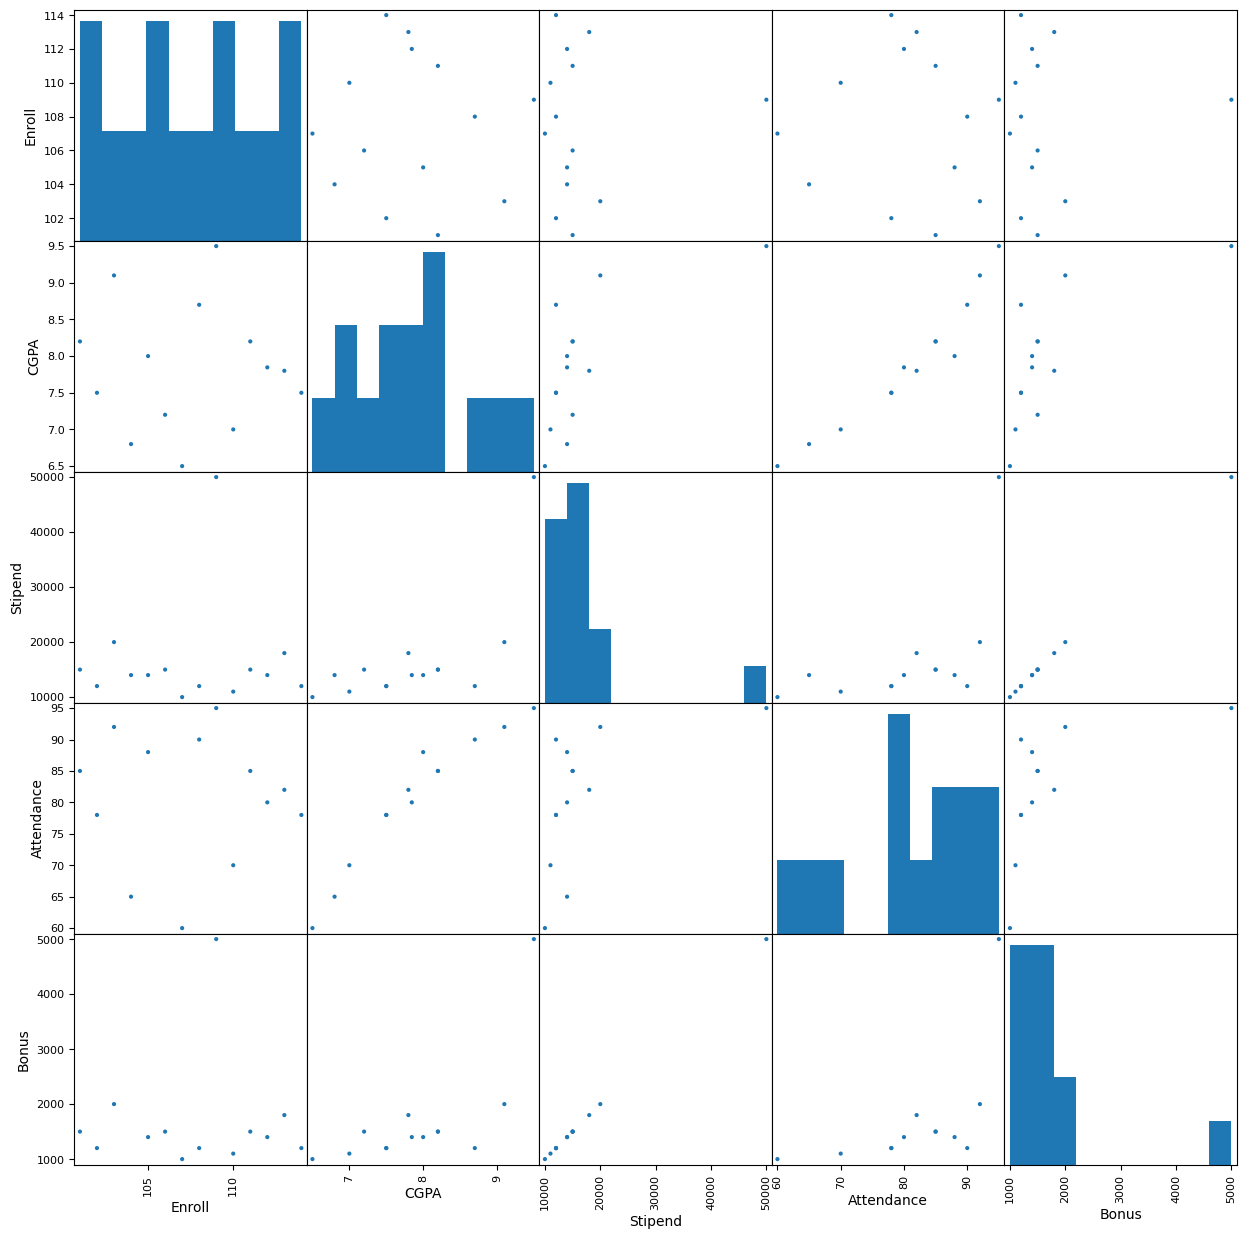

In [235]:
import matplotlib.pyplot as plt  
import pandas as pd

pd.plotting.scatter_matrix(data,figsize=[15,15],alpha=1)
plt.show()


In [249]:
pd.crosstab(data['Placed'],data['Branch'],margins=True)

Branch,CE,CSE,IT,All
Placed,,,,
No,3,2,2,7
Yes,0,4,3,7
All,3,6,5,14


<Axes: >

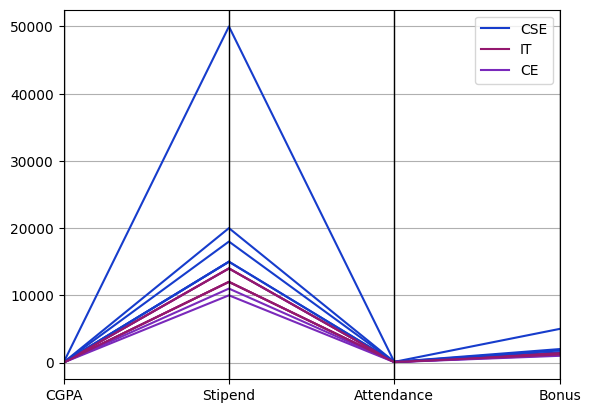

In [248]:
pd.plotting.parallel_coordinates(data,'Branch',cols=['CGPA','Stipend','Attendance','Bonus'])
